In [1]:
# initialization
import numpy as np
# importing Qiskit
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit, transpile
from qiskit_aer import QasmSimulator, Aer
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import math as math
import Utilities as util

# import basic plot tools
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


Credit qcml-7

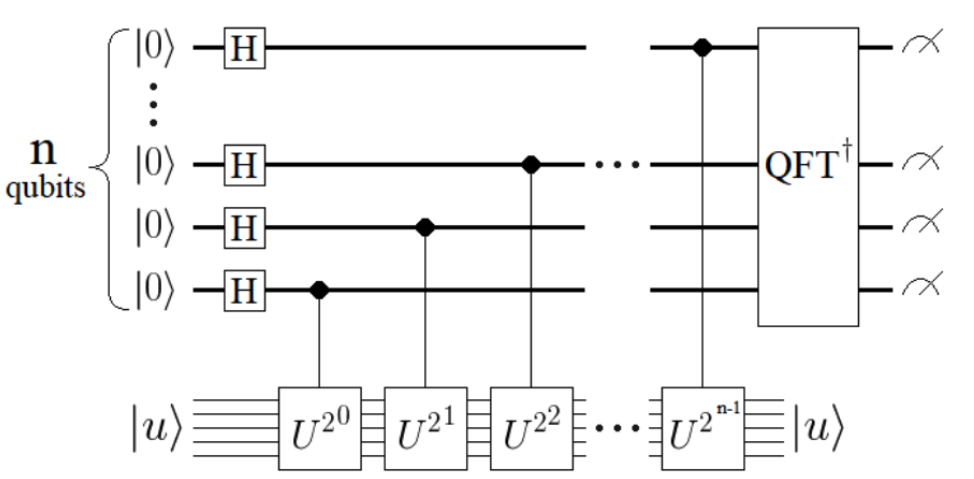

Implement U as $ U|u⟩ = e^{2πi\phi} |u⟩$. Note here unlike the theory $\phi$ is a fraction of the whole $2\pi$


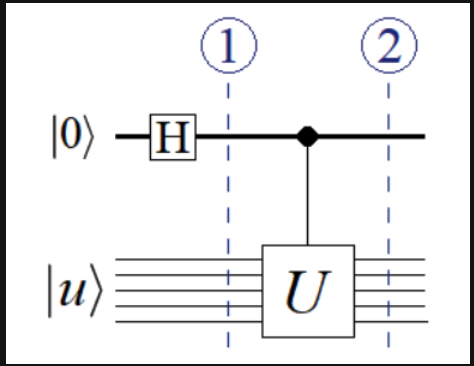


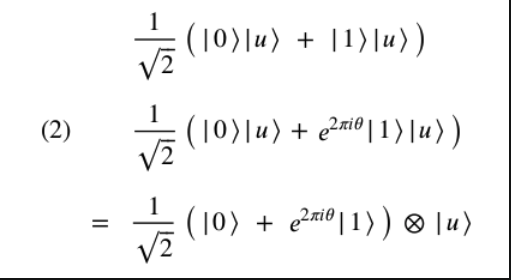

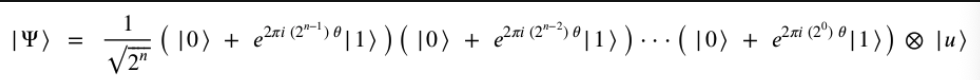

Lets apply $ QFT^\dag $ for three qubits then it looks like this

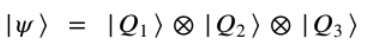

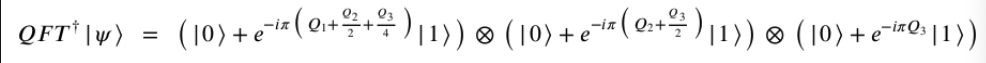

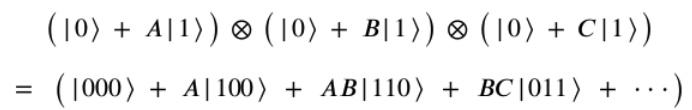

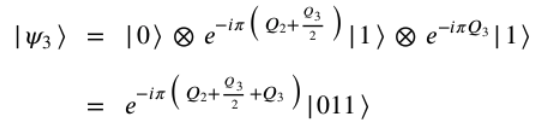

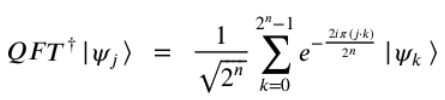

Let us now combine and build a QPE circuit. First controlled gates from |u> to counting qubits

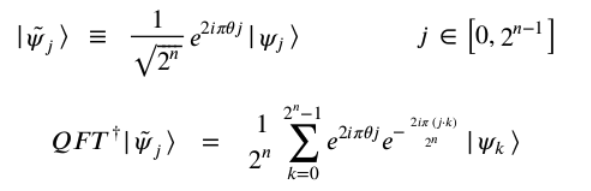

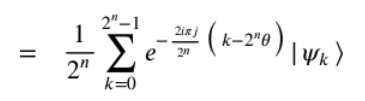


In [2]:
# Implementing the above DFT purely classicaly to und how the coefficients come into play. 

n = 4
phi = 0.3125
N = 2**n

# step 1 - create the list of binary strings and their corresponding decimal values
binary_strings = [format(i, f'0{n}b') for i in range(N)] # e.g. format(5, '07b')   # → '0000101'   (5 in binary, padded to 7 digits)
binary_decimals = [i/N for i in range(N)]

# step 2 implement the formula for controlled gates + QFTDag coefficients from above
amplitudes = np.zeros(N, dtype=complex)
for k in range(N):
    for l in range(N): # j is used for iota so using l for j in above summation
        amplitudes[k] += (1/N * np.exp(-2j * np.pi * l * (k-N*phi) / N)) 
        # sum all l's for the inner loop so index amp is obtained

# step 3 print the probablities and state vector
print("Binary strings and their corresponding probablities:")
for binary, amplitude, decimal in zip(binary_strings, amplitudes, binary_decimals):
    print(f"{binary}: (probability: {abs(amplitude)**2:.4f}, decimal: {decimal:.4f})")



Binary strings and their corresponding probablities:
0000: (probability: 0.0000, decimal: 0.0000)
0001: (probability: 0.0000, decimal: 0.0625)
0010: (probability: 0.0000, decimal: 0.1250)
0011: (probability: 0.0000, decimal: 0.1875)
0100: (probability: 0.0000, decimal: 0.2500)
0101: (probability: 1.0000, decimal: 0.3125)
0110: (probability: 0.0000, decimal: 0.3750)
0111: (probability: 0.0000, decimal: 0.4375)
1000: (probability: 0.0000, decimal: 0.5000)
1001: (probability: 0.0000, decimal: 0.5625)
1010: (probability: 0.0000, decimal: 0.6250)
1011: (probability: 0.0000, decimal: 0.6875)
1100: (probability: 0.0000, decimal: 0.7500)
1101: (probability: 0.0000, decimal: 0.8125)
1110: (probability: 0.0000, decimal: 0.8750)
1111: (probability: 0.0000, decimal: 0.9375)


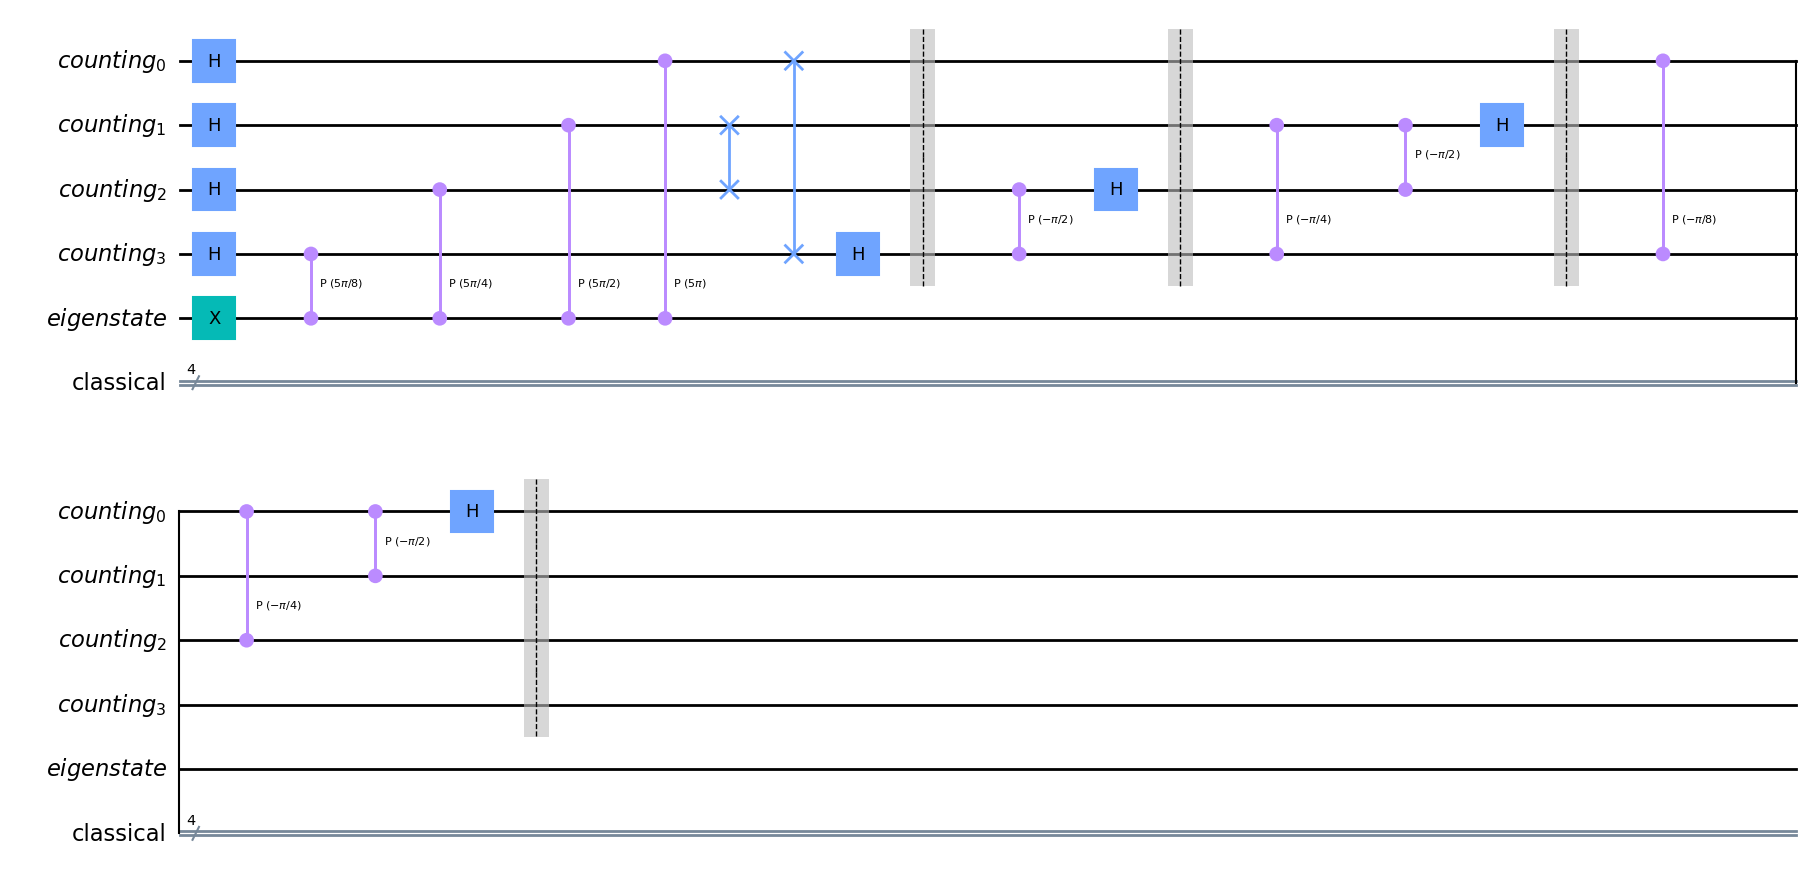

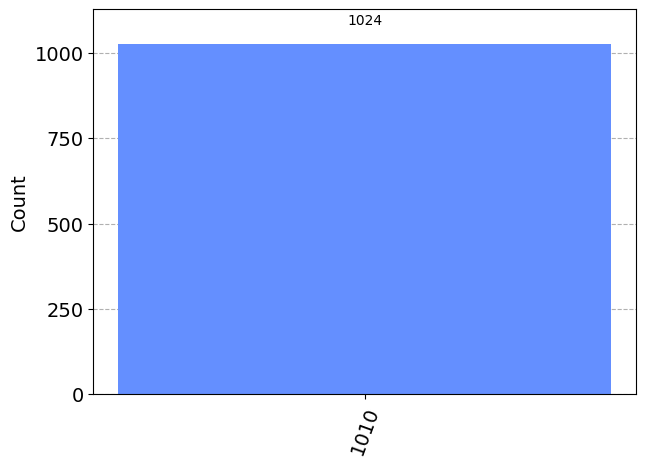

In [3]:
# implement QPE with quantum circuits
n = 4
phi = 0.3125
theta = 2 * np.pi * phi

qreg_counting = QuantumRegister(n, name='counting')
qreg_eigenstate = QuantumRegister(1, name='eigenstate')
classicalreg = ClassicalRegister(n, name='classical')
qc = QuantumCircuit(qreg_counting, qreg_eigenstate, classicalreg)

#Step 1:
# create superposition with Hadamards
qc.h(qreg_counting)

#Step2:
# eigen state is |1> becos if dont know the eigen state of U we can use a superposition of all eigen states
qc.x(qreg_eigenstate[0]) # |1> state

#Step 3:
# apply controlled-U operations
for k in range(n):
    qc.cp(theta * (2 ** k), qreg_counting[n-1-k], qreg_eigenstate[0]) # controlled phase shift

'''
What Utilities QFT outputs for |11⟩
QFT|11⟩ = (1/2)(|00⟩ - |01⟩ - i|10⟩ + i|11⟩)

What QPE controlled-U produces (phi=0.75, n=2)
QPE state = (1/2)(|00⟩ - i|01⟩ - |10⟩ + i|11⟩)

These two are NOT the same — but look carefully, the |01⟩ and |10⟩ terms are swapped!

QFT|11⟩  = (1/2)(|00⟩  -  |01⟩  - i|10⟩  + i|11⟩)
QPE state = (1/2)(|00⟩  - i|01⟩  -  |10⟩  + i|11⟩)
                          ↕ swapped ↕

So literally:

QPE state = SWAP( QFT|11⟩ )

'''

for i in range(n//2):
    qc.swap(qreg_counting[i], qreg_counting[n-1-i])

qc.compose(util.QFT_dag(qreg_counting.size), inplace=True)
display(qc.draw('mpl', style='clifford'))

qc.measure(qreg_counting, classicalreg)
M_simulator = QasmSimulator()
results = M_simulator.run(qc, shots=1024).result()
display(plot_histogram(results.get_counts()))

